In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

In [6]:
df = pd.read_csv('creditcard.csv')

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

# 2. Eksplorasi Awal dan Pra-pemrosesan

Hitung distribusi kelas

In [7]:
class_dist = df['Class'].value_counts()
print("Distribusi Kelas:\n", class_dist)

Distribusi Kelas:
 Class
0    284315
1       492
Name: count, dtype: int64


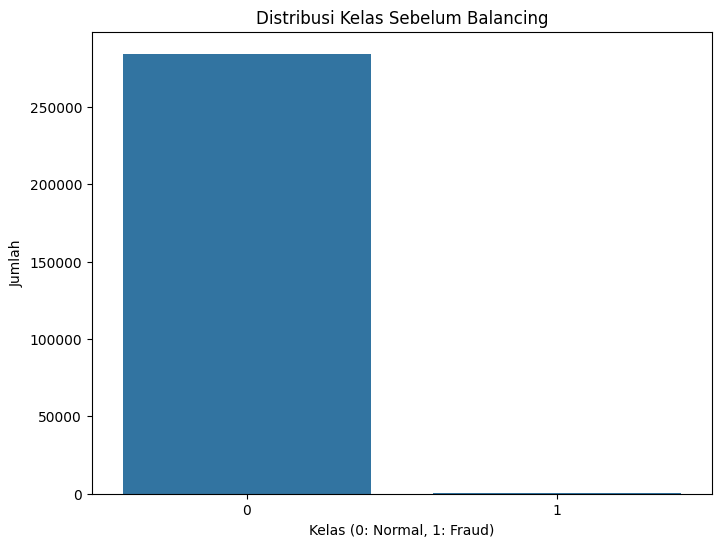

In [8]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df)
plt.title('Distribusi Kelas Sebelum Balancing')
plt.xlabel('Kelas (0: Normal, 1: Fraud)')
plt.ylabel('Jumlah')
plt.show()

In [9]:
print("\nPersentase Kelas:")
print(class_dist / class_dist.sum() * 100)


Persentase Kelas:
Class
0    99.827251
1     0.172749
Name: count, dtype: float64


Normalisasi Fitur Numerik

In [10]:
X = df.drop('Class', axis=1)
y = df['Class']

Normalisasi menggunakan Min-Max Scaling

In [11]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [12]:
print("\nContoh data setelah normalisasi:")
print(X_scaled.head())


Contoh data setelah normalisasi:
       Time        V1        V2        V3        V4        V5        V6  \
0  0.000000  0.935192  0.766490  0.881365  0.313023  0.763439  0.267669   
1  0.000000  0.978542  0.770067  0.840298  0.271796  0.766120  0.262192   
2  0.000006  0.935217  0.753118  0.868141  0.268766  0.762329  0.281122   
3  0.000006  0.941878  0.765304  0.868484  0.213661  0.765647  0.275559   
4  0.000012  0.938617  0.776520  0.864251  0.269796  0.762975  0.263984   

         V7        V8        V9  ...       V20       V21       V22       V23  \
0  0.266815  0.786444  0.475312  ...  0.582942  0.561184  0.522992  0.663793   
1  0.264875  0.786298  0.453981  ...  0.579530  0.557840  0.480237  0.666938   
2  0.270177  0.788042  0.410603  ...  0.585855  0.565477  0.546030  0.678939   
3  0.266803  0.789434  0.414999  ...  0.578050  0.559734  0.510277  0.662607   
4  0.268968  0.782484  0.490950  ...  0.584615  0.561327  0.547271  0.663392   

        V24       V25       V26   

# 3.Data Balancing

Sebelum Balancing

In [13]:
print("Sebelum balancing:")
print("Jumlah kelas 0:", sum(y == 0))
print("Jumlah kelas 1:", sum(y == 1))

Sebelum balancing:
Jumlah kelas 0: 284315
Jumlah kelas 1: 492


Penerapan SMOTE (Oversampling)

In [14]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print("\nSetelah SMOTE:")
print("Jumlah kelas 0:", sum(y_resampled == 0))
print("Jumlah kelas 1:", sum(y_resampled == 1))


Setelah SMOTE:
Jumlah kelas 0: 284315
Jumlah kelas 1: 284315


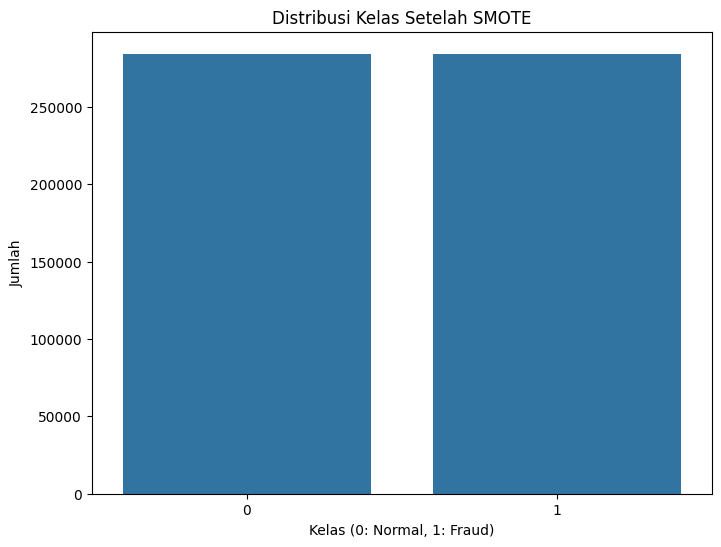

In [15]:
plt.figure(figsize=(8, 6))
sns.countplot(x=y_resampled)
plt.title('Distribusi Kelas Setelah SMOTE')
plt.xlabel('Kelas (0: Normal, 1: Fraud)')
plt.ylabel('Jumlah')
plt.show()

Penerapan Random Undersampling (Alternatif)

In [16]:
rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X_scaled, y)

print("\nSetelah Random Undersampling:")
print("Jumlah kelas 0:", sum(y_under == 0))
print("Jumlah kelas 1:", sum(y_under == 1))


Setelah Random Undersampling:
Jumlah kelas 0: 492
Jumlah kelas 1: 492


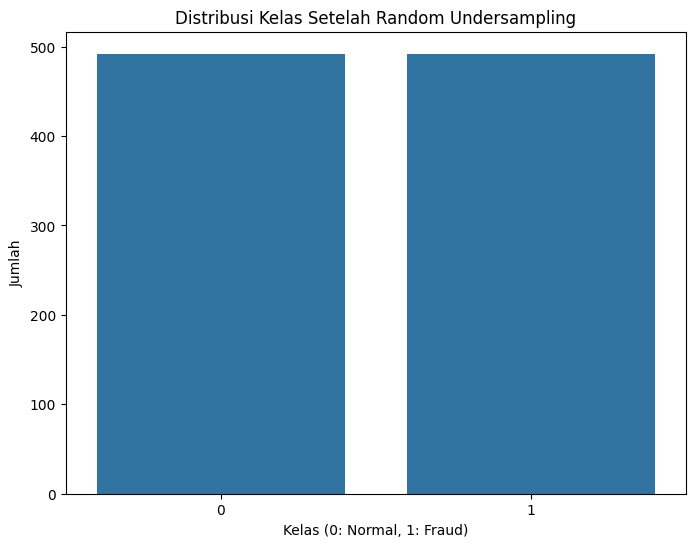

In [17]:
plt.figure(figsize=(8, 6))
sns.countplot(x=y_under)
plt.title('Distribusi Kelas Setelah Random Undersampling')
plt.xlabel('Kelas (0: Normal, 1: Fraud)')
plt.ylabel('Jumlah')
plt.show()

# 4. Data Splitting

Split Data yang Sudah Di-balance (Menggunakan SMOTE)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, 
    test_size=0.2, 
    random_state=42,
    stratify=y_resampled
)

print("\nDistribusi di Training Set:")
print(pd.Series(y_train).value_counts())
print("\nDistribusi di Test Set:")
print(pd.Series(y_test).value_counts())


Distribusi di Training Set:
Class
0    227452
1    227452
Name: count, dtype: int64

Distribusi di Test Set:
Class
1    56863
0    56863
Name: count, dtype: int64


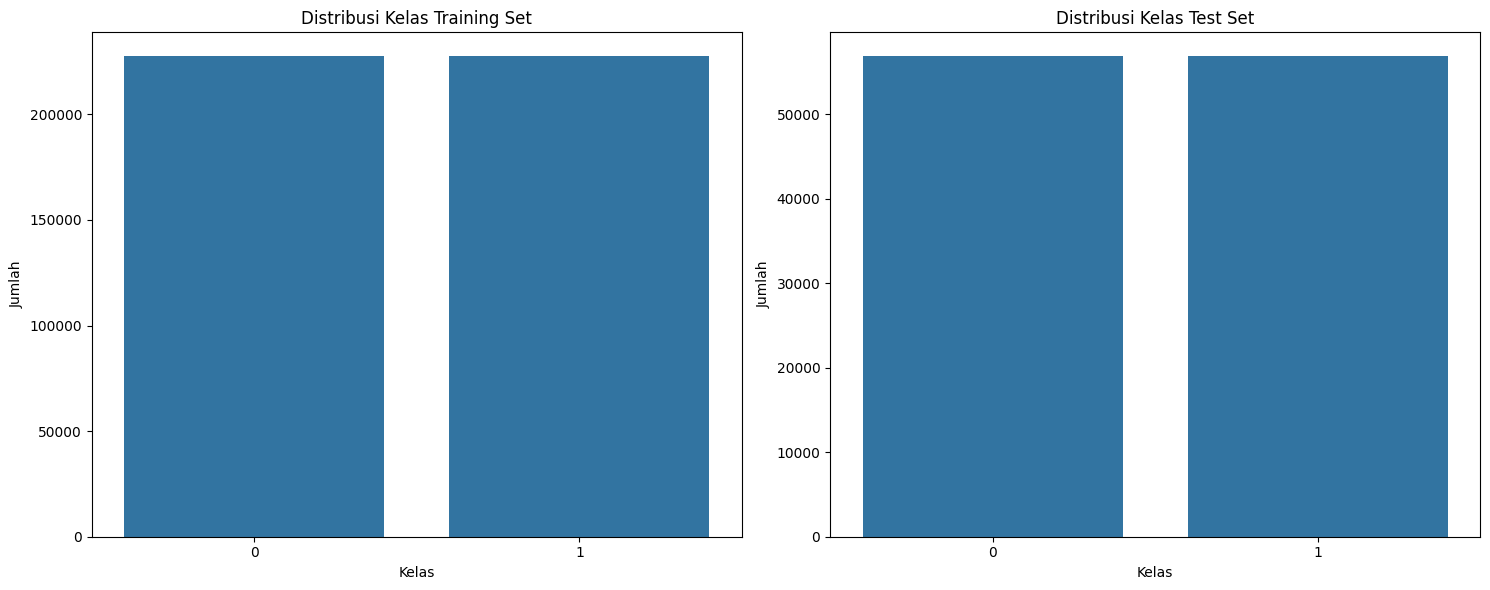

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
sns.countplot(x=y_train, ax=ax1)
ax1.set_title('Distribusi Kelas Training Set')
ax1.set_xlabel('Kelas')
ax1.set_ylabel('Jumlah')

sns.countplot(x=y_test, ax=ax2)
ax2.set_title('Distribusi Kelas Test Set')
ax2.set_xlabel('Kelas')
ax2.set_ylabel('Jumlah')

plt.tight_layout()
plt.show()

Split Data Asli (Tanpa Balancing) untuk Perbandingan

In [20]:
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_scaled, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print("\nDistribusi Data Asli di Training Set:")
print(pd.Series(y_train_orig).value_counts())
print("\nDistribusi Data Asli di Test Set:")
print(pd.Series(y_test_orig).value_counts())


Distribusi Data Asli di Training Set:
Class
0    227451
1       394
Name: count, dtype: int64

Distribusi Data Asli di Test Set:
Class
0    56864
1       98
Name: count, dtype: int64
